# Preprocesamiento y Modelado

## 1. Importaciones y configuración

In [3]:
import warnings
warnings.filterwarnings('ignore')

import random
import time
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import loguniform, uniform, randint

# Pipelines
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import clone

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Balanceo
from imblearn.over_sampling import SMOTE, ADASYN

# Modelos
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Búsqueda y validación
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV
)

# Métricas
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, precision_score, recall_score
)

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.options.display.float_format = '{:,.4f}'.format

## 2. Limpieza de datos

En el EDA identificamos que `TotalCharges` viene como string en el dataset original de Kaggle y los clientes con `tenure = 0` tienen `TotalCharges` vacío.

In [4]:
df = pd.read_csv('../data/telco-churn.csv')

# Convertir TotalCharges a numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Variable objetivo a binario
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Eliminar ID
df = df.drop(columns=['customerID'], errors='ignore')

print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
print(f'Distribución Churn: {df["Churn"].value_counts().to_dict()}')
print(f'Ratio desbalance: {df["Churn"].value_counts()[0] / df["Churn"].value_counts()[1]:.2f}:1')

Filas: 7043 | Columnas: 20
Distribución Churn: {0: 5174, 1: 1869}
Ratio desbalance: 2.77:1


El dataset quedó compuesto por 7,043 filas y 20 columnas después de eliminar customerID por ser un identificador sin valor predictivo. La variable Churn fue transformada a formato binario, con 5,174 clientes en la categoría 0 (no abandonan) y 1,869 en la categoría 1 (sí abandonan). El ratio de desbalance es de 2.77 a 1, lo que indica que por cada cliente que abandona hay casi tres que permanecen. Este nivel de desbalance no es extremo pero sí lo suficientemente marcado como para justificar el uso de técnicas de balanceo y métricas adecuadas durante el modelado. Se volvió a hacer la limpieza para tener los datos limpios guardados como variable en este notebook.

## 3. Feature Engineering y selección de variables

Se identifican las variables categóricas y numéricas que aportarán al modelo.

In [5]:
TARGET = 'Churn'

FEATURES_CAT = df.drop(columns=[TARGET]).select_dtypes(include='object').columns.tolist()
FEATURES_NUM = df.drop(columns=[TARGET]).select_dtypes(include='number').columns.tolist()
FEATURES_ALL = FEATURES_CAT + FEATURES_NUM

X = df[FEATURES_ALL].copy()
y = df[TARGET].astype(int)

print(f'Variables predictoras: {len(FEATURES_ALL)}')
print(f'  Numéricas   ({len(FEATURES_NUM)}): {FEATURES_NUM}')
print(f'  Categóricas ({len(FEATURES_CAT)}): {FEATURES_CAT}')
print(f'\nVariable objetivo: {TARGET}')
print(y.value_counts())

Variables predictoras: 19
  Numéricas   (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
  Categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Variable objetivo: Churn
Churn
0    5174
1    1869
Name: count, dtype: int64


Para las variables categóricas se utiliza OneHotEncoder porque ninguna de ellas tiene un orden natural. Gender, Partner, Dependents, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling y PaymentMethod son todas variables nominales, sus categorías no implican jerarquía. Si se usara LabelEncoder, el modelo podría interpretar erróneamente que una categoría es mayor o menor que otra, lo cual no tiene sentido en estos datos. Para las variables numéricas se aplica StandardScaler porque sus escalas son muy diferentes. Tenure va de 0 a 72, MonthlyCharges de 18 a 118 y TotalCharges alcanza valores de varios miles. El escalado estandariza todas las variables numéricas con media 0 y desviación estándar 1, eliminando ese problema sin alterar la forma de la distribución original.

## 4. Preprocesamiento con ColumnTransformer

Se construye un preprocesador robusto con sub-pipelines independientes para variables numéricas y categóricas, incluyendo `SimpleImputer` como capa de seguridad ante posibles valores faltantes.

- **Numérico:** `SimpleImputer(mediana)` → `StandardScaler`
- **Categórico:** `SimpleImputer(moda)` → `OneHotEncoder(drop='first')` para evitar multicolinealidad

In [6]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer,  FEATURES_NUM),
        ('cat', categorical_transformer, FEATURES_CAT)
    ],
    remainder='drop'
)

print('Preprocesador definido (ColumnTransformer)')
print('  Numérico:    Imputer(mediana) → StandardScaler')
print('  Categórico:  Imputer(moda)   → OneHotEncoder(drop=first)')

Preprocesador definido (ColumnTransformer)
  Numérico:    Imputer(mediana) → StandardScaler
  Categórico:  Imputer(moda)   → OneHotEncoder(drop=first)


Todo el preprocesamiento va dentro del Pipeline para evitar data leakage. Si las transformaciones se aplicaran antes de separar los datos, el modelo usaría información del conjunto de prueba durante el entrenamiento. La mediana, la moda, la media y la desviación estándar se calculan solo con los datos de entrenamiento y luego se aplican al conjunto de prueba. Esto garantiza una evaluación realista con datos no vistos. En la tubería numérica se imputa con la mediana por su resistencia a valores atípicos y se aplica StandardScaler. En la tubería categórica se imputa con la moda y se usa OneHotEncoder con drop='first' para evitar multicolinealidad y handle_unknown='ignore' para manejar categorías nuevas en producción.

## 5. Split estratificado

Se dividen los datos en 80% entrenamiento y 20% prueba de forma estratificada para garantizar que cada partición mantiene la proporción original de clases.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = y
)

print(f'Split estratificado: 80% Train / 20% Test')
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'\nDistribución en train:')
print(y_train.value_counts(normalize=True).round(3))
print(f'\nDistribución en test:')
print(y_test.value_counts(normalize=True).round(3))

Split estratificado: 80% Train / 20% Test
Train: 5,634 | Test: 1,409

Distribución en train:
Churn
0   0.7350
1   0.2650
Name: proportion, dtype: float64

Distribución en test:
Churn
0   0.7350
1   0.2650
Name: proportion, dtype: float64


La división de los datos se realizó de forma estratificada en un 80% para entrenamiento y un 20% para prueba, obteniendo 5,634 registros en el conjunto de entrenamiento y 1,409 en el de prueba. La estratificación cumplió su objetivo, ya que la proporción de Churn se mantiene idéntica en ambos conjuntos, con un 73.50% de clientes que no abandonan y un 26.50% que sí lo hacen, valores que coinciden con la distribución original del dataset. 

## 6. Validación cruzada y configuración de métricas

Se usa `StratifiedKFold` con 5 particiones para preservar la proporción de clases en cada fold. La métrica de optimización principal es **F1-Score** (`refit='f1'`), apropiada para datasets desbalanceados porque pondera Precision y Recall. Se registran múltiples métricas simultáneamente para análisis posterior.

In [8]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

SCORING_MULTIPLE = {
    'roc_auc'  : 'roc_auc',
    'pr_auc'   : 'average_precision',
    'f1'       : 'f1',
    'recall'   : 'recall',
    'precision': 'precision',
}

# Ratio de desbalance para scale_pos_weight (XGBoost) y class_weight
n_no_churn = (y_train == 0).sum()
n_churn    = (y_train == 1).sum()
SCALE_WEIGHT = n_no_churn / n_churn

print(f'Validación: StratifiedKFold (k=5, shuffle=True, seed={RANDOM_STATE})')
print(f'Métrica de optimización (refit): f1')
print(f'Métricas registradas: {list(SCORING_MULTIPLE.keys())}')
print(f'\nRatio desbalance (No Churn / Churn): {SCALE_WEIGHT:.2f}')

Validación: StratifiedKFold (k=5, shuffle=True, seed=42)
Métrica de optimización (refit): f1
Métricas registradas: ['roc_auc', 'pr_auc', 'f1', 'recall', 'precision']

Ratio desbalance (No Churn / Churn): 2.77


La métrica F1 se eligió como criterio de optimización sobre Accuracy y AUC debido al desbalance de clases presente en el dataset. La Accuracy no es adecuada en este contexto, ya que un modelo que simplemente prediga siempre la clase mayoritaria alcanzaría un 73.5% de exactitud sin detectar ningún cliente que abandona, lo cual es inútil para el objetivo del negocio. AUC mide la capacidad general de discriminación del modelo y es útil para comparar modelos, pero no considera explícitamente el punto de corte ni penaliza los falsos negativos de forma directa. El F1, en cambio, combina precision y recall en una sola métrica equilibrada, lo que obliga al modelo a identificar correctamente a los clientes que abandonan y a la vez evitar clasificar erróneamente a los que no lo hacen.

## 7. Pipeline de entrenamiento

Se define una función reutilizable que entrena cada modelo bajo **4 estrategias de balanceo**:
- `sin_balanceo`: sin ninguna técnica adicional
- `smote`: Synthetic Minority Oversampling Technique
- `adasyn`: Adaptive Synthetic Sampling (variante adaptativa de SMOTE)
- `weights`: ajuste de pesos de clase (`class_weight='balanced'` o `scale_pos_weight`)

Se usa **`RandomizedSearchCV`** en lugar de `GridSearchCV` que permite explorar rangos continuos con distribuciones estadísticas (`loguniform`, `uniform`, `randint`), encuentra combinaciones óptimas en menos tiempo y es más robusto que una búsqueda exhaustiva en grids discretos.

El parámetro `verbose=1` muestra el progreso interno de cada `RandomizedSearchCV`, permitiendo ver cuántos fits van completados.

In [10]:
BALANCEADORES = {
    'sin_balanceo': None,
    'smote'       : SMOTE(random_state=RANDOM_STATE),
    'adasyn'      : ADASYN(random_state=RANDOM_STATE),
    'weights'     : 'weights'
}


def optimizar_modelo(
    nombre_modelo,
    make_pipeline_fn,
    param_dist,
    param_dist_weights=None,
    n_iter=20
):
    """
    Entrena un modelo bajo 4 estrategias de balanceo con RandomizedSearchCV.
    Registra métricas en CV y en test para cada combinación.
    """
    resultados = {'modelo': nombre_modelo, 'random_search': {}}

    print(f"\n{'='*60}")
    print(f"  OPTIMIZANDO: {nombre_modelo}")
    print(f"{'='*60}")

    for nombre_bal, balancer in BALANCEADORES.items():

        print(f"\n{'─'*60}")
        print(f"  BALANCEO: {nombre_bal.upper()}")
        print(f"{'─'*60}")

        pd_actual = (
            param_dist_weights
            if (nombre_bal == 'weights' and param_dist_weights)
            else param_dist
        )

        print(f"\n  RandomizedSearchCV ({n_iter} iteraciones × 5 folds = {n_iter*5} fits)...")
        start = time.time()

        rs = RandomizedSearchCV(
            estimator           = make_pipeline_fn(balancer=balancer),
            param_distributions = pd_actual,
            n_iter              = n_iter,
            cv                  = CV,
            scoring             = SCORING_MULTIPLE,
            refit               = 'f1',
            n_jobs              = -1,
            random_state        = RANDOM_STATE,
            verbose             = 1      # ← progreso interno
        )
        rs.fit(X_train, y_train)

        cv_results = rs.cv_results_
        elapsed    = time.time() - start

        # Métricas en CV
        metrics_cv = {
            'roc_auc'  : cv_results['mean_test_roc_auc'][rs.best_index_],
            'pr_auc'   : cv_results['mean_test_pr_auc'][rs.best_index_],
            'f1'       : cv_results['mean_test_f1'][rs.best_index_],
            'recall'   : cv_results['mean_test_recall'][rs.best_index_],
            'precision': cv_results['mean_test_precision'][rs.best_index_],
        }

        # Métricas en test
        est     = rs.best_estimator_
        y_prob  = est.predict_proba(X_test)[:, 1]
        y_pred  = est.predict(X_test)

        resultados['random_search'][nombre_bal] = {
            'score_cv'    : rs.best_score_,
            'tiempo'      : elapsed,
            'params'      : rs.best_params_,
            'estimator'   : est,
            'metrics_cv'  : metrics_cv,
            'roc_auc_test': roc_auc_score(y_test, y_prob),
            'pr_auc_test' : average_precision_score(y_test, y_prob),
            'report'      : classification_report(
                y_test, y_pred,
                target_names=['No Churn', 'Churn'],
                output_dict=True
            )
        }

        print(f"\n  ✅ Listo en {elapsed/60:.2f} min")
        print(f"  F1 CV: {rs.best_score_:.4f}")
        print("  " + " | ".join([f"{k}: {v:.4f}" for k, v in metrics_cv.items()]))
        print(f"  ROC-AUC test: {resultados['random_search'][nombre_bal]['roc_auc_test']:.4f} "
              f"| PR-AUC test: {resultados['random_search'][nombre_bal]['pr_auc_test']:.4f}")

    return resultados


GridSearchCV evalúa todas las combinaciones posibles de los hiperparámetros definidos en una cuadrícula, lo que garantiza encontrar la mejor combinación pero se vuelve muy costoso cuando el espacio de búsqueda es grande. RandomizedSearchCV, en cambio, prueba un número fijo de combinaciones aleatorias, lo que permite explorar un espacio amplio en menos tiempo y con igual probabilidad de encontrar buenos resultados. Para hiperparámetros continuos o grids grandes, RandomizedSearchCV es más eficiente porque evita probar combinaciones poco prometedoras y concentra el presupuesto computacional en una muestra representativa del espacio de búsqueda.

## 8. Entrenamiento de modelos

Se entrenan cuatro clasificadores con los hiperparámetros adicionales recomendados en el enunciado, usando distribuciones continuas en `RandomizedSearchCV` para una exploración más rica del espacio de hiperparámetros.

El prefijo `classifier__` indica a `RandomizedSearchCV` a qué paso del `ImbPipeline` pertenece cada parámetro.

### Random Forest

In [11]:
def make_rf_pipeline(params=None, balancer=None):
    cw = 'balanced' if balancer == 'weights' else None

    default_params = dict(
        n_estimators      = 100,
        class_weight      = cw,
        random_state      = RANDOM_STATE,
        n_jobs            = -1
    )
    if params:
        default_params.update(params)

    steps = [('preprocessor', clone(preprocessor))]
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', clone(balancer)))
    steps.append(('classifier', RandomForestClassifier(**default_params)))

    return ImbPipeline(steps=steps)


# Hiperparámetros del enunciado: min_samples_split, min_samples_leaf,
# max_features, bootstrap, criterion
param_dist_rf = {
    'classifier__n_estimators'    : randint(50, 300),
    'classifier__min_samples_split': randint(2, 20),
    'classifier__min_samples_leaf' : randint(1, 10),
    'classifier__max_features'     : ['sqrt', 'log2'],
    'classifier__bootstrap'        : [True, False],
    'classifier__criterion'        : ['gini', 'entropy'],
}

resultados_rf = optimizar_modelo(
    nombre_modelo    = 'RandomForest',
    make_pipeline_fn = make_rf_pipeline,
    param_dist       = param_dist_rf,
    n_iter           = 20
)


  OPTIMIZANDO: RandomForest

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  RandomizedSearchCV (20 iteraciones × 5 folds = 100 fits)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

  ✅ Listo en 0.12 min
  F1 CV: 0.5753
  roc_auc: 0.8437 | pr_auc: 0.6589 | f1: 0.5753 | recall: 0.4983 | precision: 0.6810
  ROC-AUC test: 0.8417 | PR-AUC test: 0.6526

────────────────────────────────────────────────────────────
  BALANCEO: SMOTE
────────────────────────────────────────────────────────────

  RandomizedSearchCV (20 iteraciones × 5 folds = 100 fits)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

  ✅ Listo en 0.15 min
  F1 CV: 0.6333
  roc_auc: 0.8432 | pr_auc: 0.6487 | f1: 0.6333 | recall: 0.7050 | precision: 0.5750
  ROC-AUC test: 0.8421 | PR-AUC test: 0.6394

────────────────────────────────────────────────────────────
  BALANCEO: ADASYN
─────────────

Sin balanceo, el recall es bajo, solo detecta el 50% de los clientes que abandonan, aunque la precision es la más alta con un 68%. SMOTE y ADASYN mejoran el recall a poco más del 70%, pero la precision baja a cerca del 57%, con resultados casi idénticos entre ambas técnicas. La estrategia de pesos balanceados obtiene el mejor desempeño general, con el F1 más alto de 0.6387, un recall de 75.7% y una precision de 55.3%. WEIGHTS logra el mayor aumento de recall, detectando 25 puntos porcentuales más de abandonos que sin balanceo, con una caída controlada de solo 13 puntos en precision, y además presenta las mejores métricas en test.

### XGBoost

In [12]:
def make_xgb_pipeline(params=None, balancer=None):
    spw = SCALE_WEIGHT if balancer == 'weights' else 1

    default_params = dict(
        n_estimators      = 100,
        scale_pos_weight  = spw,
        eval_metric       = 'logloss',
        random_state      = RANDOM_STATE,
        verbosity         = 0,
        n_jobs            = -1
    )
    if params:
        default_params.update(params)

    steps = [('preprocessor', clone(preprocessor))]
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', clone(balancer)))
    steps.append(('classifier', XGBClassifier(**default_params)))

    return ImbPipeline(steps=steps)


# Hiperparámetros del enunciado: subsample, colsample_bytree, gamma,
# min_child_weight, reg_alpha, reg_lambda, scale_pos_weight
param_dist_xgb_base = {
    'classifier__n_estimators'   : randint(50, 300),
    'classifier__max_depth'      : randint(3, 7),
    'classifier__learning_rate'  : loguniform(0.01, 0.3),
    'classifier__subsample'      : uniform(0.6, 0.4),
    'classifier__colsample_bytree': uniform(0.6, 0.4),
    'classifier__gamma'          : uniform(0, 0.5),
    'classifier__min_child_weight': randint(1, 10),
    'classifier__reg_alpha'      : loguniform(1e-4, 1.0),
    'classifier__reg_lambda'     : loguniform(0.1, 5.0),
}

param_dist_xgb_weights = {
    **param_dist_xgb_base,
    'classifier__scale_pos_weight': uniform(1, SCALE_WEIGHT * 1.5)
}

resultados_xgb = optimizar_modelo(
    nombre_modelo      = 'XGBoost',
    make_pipeline_fn   = make_xgb_pipeline,
    param_dist         = param_dist_xgb_base,
    param_dist_weights = param_dist_xgb_weights,
    n_iter             = 20
)


  OPTIMIZANDO: XGBoost

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  RandomizedSearchCV (20 iteraciones × 5 folds = 100 fits)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

  ✅ Listo en 0.02 min
  F1 CV: 0.5948
  roc_auc: 0.8475 | pr_auc: 0.6650 | f1: 0.5948 | recall: 0.5338 | precision: 0.6723
  ROC-AUC test: 0.8449 | PR-AUC test: 0.6561

────────────────────────────────────────────────────────────
  BALANCEO: SMOTE
────────────────────────────────────────────────────────────

  RandomizedSearchCV (20 iteraciones × 5 folds = 100 fits)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

  ✅ Listo en 0.04 min
  F1 CV: 0.6338
  roc_auc: 0.8457 | pr_auc: 0.6531 | f1: 0.6338 | recall: 0.7625 | precision: 0.5424
  ROC-AUC test: 0.8429 | PR-AUC test: 0.6446

────────────────────────────────────────────────────────────
  BALANCEO: ADASYN
──────────────────

La estrategia de pesos balanceados en XGBoost, implementada mediante scale_pos_weight, logra el mejor rendimiento general con un F1 de 0.6393, un recall de 0.7418 y una precision de 0.5617, además de obtener las métricas más altas en test con un ROC-AUC de 0.8474 y un PR-AUC de 0.6653. A diferencia de SMOTE y ADASYN, que generan datos sintéticos y modifican la distribución original del conjunto de entrenamiento, scale_pos_weight ajusta internamente el peso de la clase minoritaria durante el entrenamiento sin alterar los datos, lo que permite al modelo penalizar más los errores en la clase positiva sin introducir ruido artificial. SMOTE alcanza un recall más alto de 0.7625 pero con una precision menor de 0.5424, lo que indica que detecta más abandonos reales a costa de generar más falsas alarmas. ADASYN obtiene un recall de 0.6763 y una precision de 0.5886, quedando por debajo de ambas estrategias en F1. La ventaja de scale_pos_weight sobre SMOTE y ADASYN es que mantiene un mejor equilibrio entre recall y precision, con una precision superior en casi dos puntos porcentuales respecto a SMOTE, y además conserva la estructura original de los datos sin sintetizar nuevas observaciones, lo que puede ser preferible cuando los datos sintéticos no logran capturar fielmente la complejidad de la clase minoritaria. Sin balanceo, XGBoost presenta un recall bajo de 0.5338, lo que confirma que aplicar pesos es necesario para este problema desbalanceado.


### CatBoost

In [13]:
def make_cat_pipeline(params=None, balancer=None):
    # CatBoost usa auto_class_weights para el balanceo por pesos
    acw = 'Balanced' if balancer == 'weights' else None

    default_params = dict(
        iterations         = 100,
        auto_class_weights = acw,
        random_seed        = RANDOM_STATE,
        verbose            = 0
    )
    if params:
        default_params.update(params)

    steps = [('preprocessor', clone(preprocessor))]
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', clone(balancer)))
    steps.append(('classifier', CatBoostClassifier(**default_params)))

    return ImbPipeline(steps=steps)


# Hiperparámetros del enunciado: l2_leaf_reg, bagging_temperature,
# border_count, random_strength, one_hot_max_size, subsample
param_dist_cat = {
    'classifier__iterations'        : randint(50, 300),
    'classifier__depth'             : randint(4, 8),
    'classifier__learning_rate'     : loguniform(0.01, 0.3),
    'classifier__l2_leaf_reg'       : loguniform(1, 10),
    'classifier__bagging_temperature': uniform(0, 1),
    'classifier__border_count'      : [32, 64, 128],
    'classifier__random_strength'   : uniform(0.1, 2),
    'classifier__one_hot_max_size'  : [2, 5, 10],
}

resultados_cat = optimizar_modelo(
    nombre_modelo    = 'CatBoost',
    make_pipeline_fn = make_cat_pipeline,
    param_dist       = param_dist_cat,
    n_iter           = 20
)


  OPTIMIZANDO: CatBoost

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  RandomizedSearchCV (20 iteraciones × 5 folds = 100 fits)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

  ✅ Listo en 0.11 min
  F1 CV: 0.5878
  roc_auc: 0.8445 | pr_auc: 0.6589 | f1: 0.5878 | recall: 0.5224 | precision: 0.6726
  ROC-AUC test: 0.8414 | PR-AUC test: 0.6541

────────────────────────────────────────────────────────────
  BALANCEO: SMOTE
────────────────────────────────────────────────────────────

  RandomizedSearchCV (20 iteraciones × 5 folds = 100 fits)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

  ✅ Listo en 0.12 min
  F1 CV: 0.6346
  roc_auc: 0.8447 | pr_auc: 0.6609 | f1: 0.6346 | recall: 0.6896 | precision: 0.5880
  ROC-AUC test: 0.8427 | PR-AUC test: 0.6564

────────────────────────────────────────────────────────────
  BALANCEO: ADASYN
─────────────────

CatBoost con pesos balanceados obtiene el recall más alto de todos los modelos, 0.7893, con un F1 de 0.6379 y una precision de 0.5353. La estrategia auto_class_weights='Balanced' supera a SMOTE y ADASYN en recall, con casi 10 puntos más que SMOTE, aunque SMOTE ofrece una precision ligeramente mayor. Frente a los otros modelos, CatBoost con pesos empata en F1 con Random Forest y XGBoost, pero destaca en recall, con 79% de abandonos detectados contra 75.7% de Random Forest y 74.2% de XGBoost. Los pesos balanceados en CatBoost logran el mejor equilibrio sin necesidad de generar datos sintéticos, priorizando la detección de churn con una caída controlada de precision. Sin balanceo, CatBoost apenas detecta el 52% de los abandonos, por debajo de sus competidores sin balanceo.

### LightGBM

In [14]:
def make_lgbm_pipeline(params=None, balancer=None):
    cw = 'balanced' if balancer == 'weights' else None

    default_params = dict(
        n_estimators  = 100,
        class_weight  = cw,
        random_state  = RANDOM_STATE,
        verbose       = -1,
        n_jobs        = -1
    )
    if params:
        default_params.update(params)

    steps = [('preprocessor', clone(preprocessor))]
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', clone(balancer)))
    steps.append(('classifier', LGBMClassifier(**default_params)))

    return ImbPipeline(steps=steps)


# Hiperparámetros del enunciado: min_child_samples, min_child_weight,
# subsample, colsample_bytree, reg_alpha, reg_lambda, max_bin
param_dist_lgbm = {
    'classifier__n_estimators'    : randint(50, 300),
    'classifier__num_leaves'      : randint(20, 100),
    'classifier__learning_rate'   : loguniform(0.01, 0.3),
    'classifier__min_child_samples': randint(10, 80),
    'classifier__min_child_weight' : loguniform(1e-4, 0.1),
    'classifier__subsample'       : uniform(0.6, 0.4),
    'classifier__colsample_bytree': uniform(0.6, 0.4),
    'classifier__reg_alpha'       : loguniform(1e-4, 1.0),
    'classifier__reg_lambda'      : loguniform(1e-4, 1.0),
    'classifier__max_bin'         : [127, 255, 512],
}

resultados_lgbm = optimizar_modelo(
    nombre_modelo    = 'LightGBM',
    make_pipeline_fn = make_lgbm_pipeline,
    param_dist       = param_dist_lgbm,
    n_iter           = 20
)


  OPTIMIZANDO: LightGBM

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  RandomizedSearchCV (20 iteraciones × 5 folds = 100 fits)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

  ✅ Listo en 1.25 min
  F1 CV: 0.5797
  roc_auc: 0.8447 | pr_auc: 0.6587 | f1: 0.5797 | recall: 0.5124 | precision: 0.6684
  ROC-AUC test: 0.8447 | PR-AUC test: 0.6625

────────────────────────────────────────────────────────────
  BALANCEO: SMOTE
────────────────────────────────────────────────────────────

  RandomizedSearchCV (20 iteraciones × 5 folds = 100 fits)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

  ✅ Listo en 1.48 min
  F1 CV: 0.6341
  roc_auc: 0.8444 | pr_auc: 0.6421 | f1: 0.6341 | recall: 0.7331 | precision: 0.5589
  ROC-AUC test: 0.8435 | PR-AUC test: 0.6369

────────────────────────────────────────────────────────────
  BALANCEO: ADASYN
─────────────────

LightGBM con pesos balanceados alcanza un recall de 0.7906, el más alto junto con CatBoost, con un F1 de 0.6341 y una precision de 0.5294. WEIGHTS fue la mejor técnica de balanceo en este modelo, con el recall más elevado aunque con la precision más baja. SMOTE obtiene el mismo F1 pero con menor recall y mayor precision. Sin balanceo, LightGBM tiene el rendimiento más bajo de todos los modelos evaluados. Frente a los demás modelos, LightGBM con pesos iguala a CatBoost en recall pero con tiempos de entrenamiento mucho mayores, 1.25 minutos contra 0.11 minutos de CatBoost y 0.02 minutos de XGBoost, sin ofrecer una mejora clara en las métricas que justifique esa diferencia de eficiencia.

## 9. Resultados y comparación

### 9.1 Tabla comparativa completa

In [15]:
TODOS_RESULTADOS = {
    'RandomForest': resultados_rf,
    'XGBoost'     : resultados_xgb,
    'CatBoost'    : resultados_cat,
    'LightGBM'    : resultados_lgbm,
}

filas = []
for nombre_modelo, resultado in TODOS_RESULTADOS.items():
    for balanceo, datos in resultado['random_search'].items():
        rep = datos['report']
        filas.append({
            'Modelo'      : nombre_modelo,
            'Balanceo'    : balanceo,
            'F1_CV'       : round(datos['metrics_cv']['f1'],        4),
            'ROC_AUC_CV'  : round(datos['metrics_cv']['roc_auc'],   4),
            'PR_AUC_CV'   : round(datos['metrics_cv']['pr_auc'],    4),
            'Recall_CV'   : round(datos['metrics_cv']['recall'],    4),
            'Precision_CV': round(datos['metrics_cv']['precision'], 4),
            'ROC_AUC_test': round(datos['roc_auc_test'],            4),
            'PR_AUC_test' : round(datos['pr_auc_test'],             4),
            'F1_test'     : round(rep['Churn']['f1-score'],         4),
            'Recall_test' : round(rep['Churn']['recall'],           4),
            'Prec_test'   : round(rep['Churn']['precision'],        4),
            'Tiempo_min'  : round(datos['tiempo'] / 60,             2),
        })

df_comparacion = pd.DataFrame(filas).sort_values('ROC_AUC_test', ascending=False).reset_index(drop=True)
display(df_comparacion)

,Modelo,Balanceo,F1_CV,ROC_AUC_CV,PR_AUC_CV,Recall_CV,Precision_CV,ROC_AUC_test,PR_AUC_test,F1_test,Recall_test,Prec_test,Tiempo_min
0,XGBoost,weights,0.6393,0.8483,0.6660,0.7418,0.5617,0.8474,0.6653,0.6322,0.7513,0.5456,0.0200
1,CatBoost,weights,0.6379,0.8467,0.6668,0.7893,0.5353,0.8454,0.6651,0.6279,0.7941,0.5192,0.1100
2,LightGBM,weights,0.6341,0.8465,0.6527,0.7906,0.5294,0.8452,0.6571,0.6334,0.7968,0.5256,1.2400
3,XGBoost,sin_balanceo,0.5948,0.8475,0.6650,0.5338,0.6723,0.8449,0.6561,0.5851,0.5241,0.6622,0.0200
4,RandomForest,weights,0.6387,0.8470,0.6634,0.7572,0.5525,0.8448,0.6585,0.6353,0.7754,0.5380,0.1000
5,LightGBM,sin_balanceo,0.5797,0.8447,0.6587,0.5124,0.6684,0.8447,0.6625,0.5706,0.5134,0.6421,1.2500
6,LightGBM,smote,0.6341,0.8444,0.6421,0.7331,0.5589,0.8435,0.6369,0.6220,0.7193,0.5479,1.4800
7,CatBoost,adasyn,0.6325,0.8456,0.6576,0.7672,0.5383,0.8430,0.6559,0.6324,0.7727,0.5352,0.1300
8,XGBoost,smote,0.6338,0.8457,0.6531,0.7625,0.5424,0.8429,0.6446,0.6320,0.7647,0.5386,0.0400
9,CatBoost,smote,0.6346,0.8447,0.6609,0.6896,0.5880,0.8427,0.6564,0.6269,0.7032,0.5656,0.1200


In [31]:
os.makedirs('../data', exist_ok=True)
df_comparacion.to_csv('../data/resultados_modelos.csv', index=False)
print('Guardado en data/resultados_modelos.csv')

Guardado en data/resultados_modelos.csv


### 9.2 Comparación por técnica de balanceo

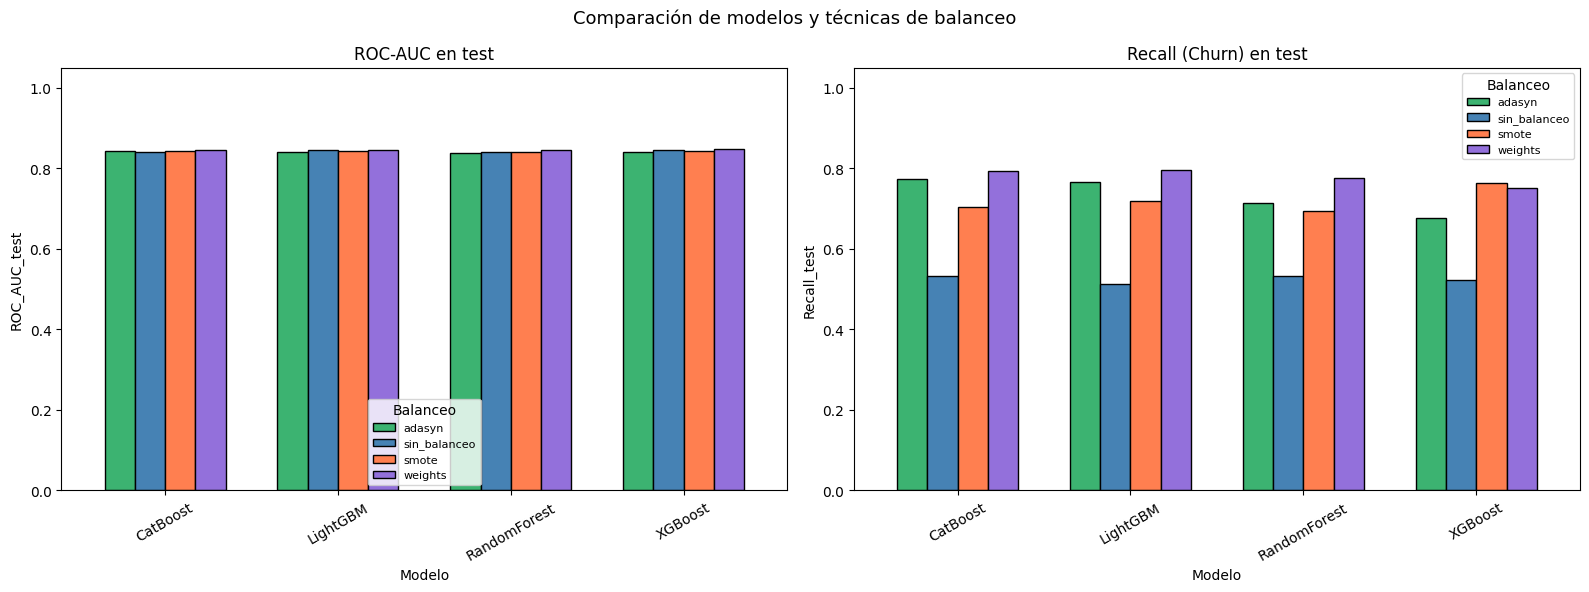

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
paleta = {'sin_balanceo': 'steelblue', 'smote': 'coral',
          'adasyn': 'mediumseagreen', 'weights': 'mediumpurple'}

for ax, metrica, titulo in zip(
    axes,
    ['ROC_AUC_test', 'Recall_test'],
    ['ROC-AUC en test', 'Recall (Churn) en test']
):
    pivot = df_comparacion.pivot(index='Modelo', columns='Balanceo', values=metrica)
    pivot.plot(kind='bar', ax=ax, color=[paleta[c] for c in pivot.columns],
               edgecolor='black', width=0.7)
    ax.set_title(titulo)
    ax.set_ylabel(metrica)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Balanceo', fontsize=8)

plt.suptitle('Comparación de modelos y técnicas de balanceo', fontsize=13)
plt.tight_layout()
plt.show()

Los resultados generales muestran que los cuatro modelos evaluados se benefician significativamente de las técnicas de balanceo. Sin balanceo, todos presentan recalls bajos, entre 0.49 y 0.53, lo que los hace inadecuados para detectar churn. Con balanceo, los recalls suben drásticamente superando el 0.70 en todos los casos.

XGBoost con pesos balanceados lidera la tabla con el F1 en test más alto de 0.6322, un recall de 0.7513 y una precision de 0.5456, además de obtener el mejor ROC-AUC en test con 0.8474. LightGBM con pesos alcanza el recall más alto en test con 0.7968, seguido muy de cerca por CatBoost con pesos con 0.7941, ambos priorizando la detección de abandonos aunque con precisiones más bajas, 0.5256 y 0.5192 respectivamente. Random Forest con pesos logra un buen equilibrio con un recall de 0.7754 y una precision de 0.5380.

CatBoost y LightGBM con pesos son la mejor opción si la prioridad es maximizar el recall, ya que detectan cerca del 79% de los abandonos reales. XGBoost con pesos ofrece el mejor balance entre precisión y recall, con el F1 más competitivo. Random Forest con pesos se mantiene como una alternativa sólida y equilibrada.

SMOTE y ADASYN muestran resultados aceptables pero inferiores a los pesos balanceados en F1, salvo en LightGBM donde SMOTE iguala en F1 a WEIGHTS pero con menor recall. Los tiempos de entrenamiento varían notablemente, XGBoost es el más rápido con 0.02 minutos, seguido de CatBoost con 0.11, Random Forest con 0.10 y LightGBM con 1.24 minutos, siendo este último el más costoso computacionalmente sin una ventaja clara que lo justifique. En conclusión, XGBoost con pesos balanceados ofrece el mejor rendimiento general considerando F1, recall, precision y eficiencia computacional.


### 9.3 Matrices de confusión

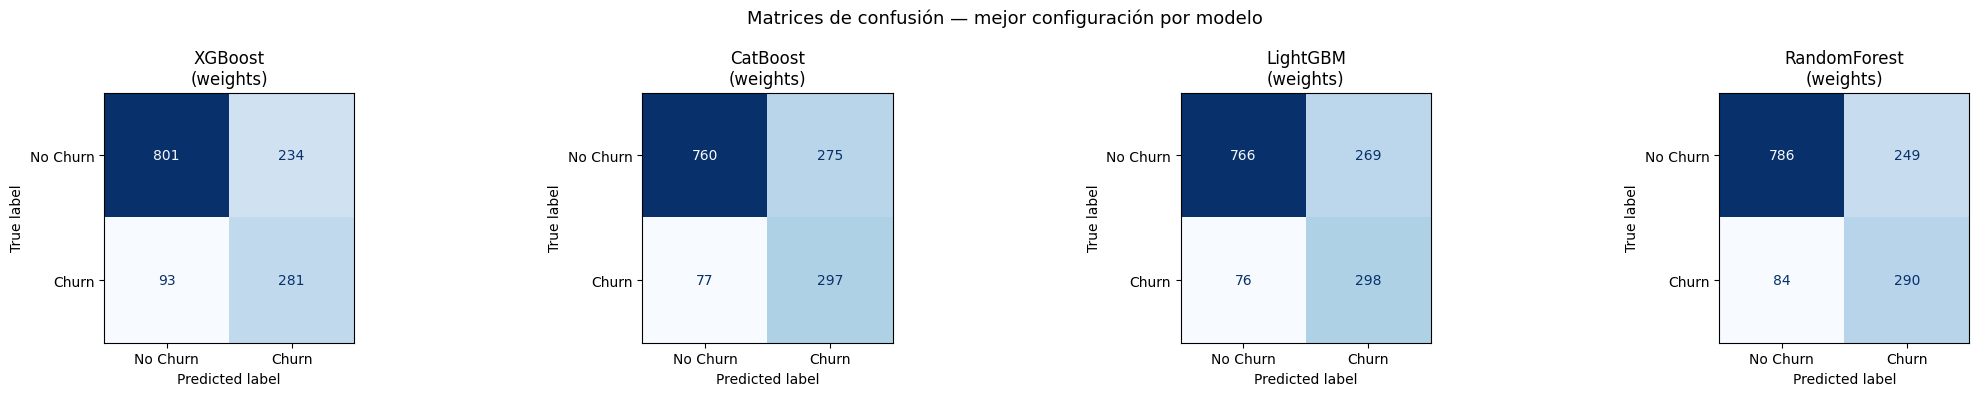

In [20]:
# Seleccionar la mejor configuración de cada modelo por ROC-AUC test
mejores = (
    df_comparacion
    .sort_values('ROC_AUC_test', ascending=False)
    .drop_duplicates(subset='Modelo')
)

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

for i, (_, fila) in enumerate(mejores.iterrows()):
    est    = TODOS_RESULTADOS[fila['Modelo']]['random_search'][fila['Balanceo']]['estimator']
    y_pred = est.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
        ax=axes[i], colorbar=False, cmap='Blues'
    )
    axes[i].set_title(f"{fila['Modelo']}\n({fila['Balanceo']})")

plt.suptitle('Matrices de confusión — mejor configuración por modelo', fontsize=13)
plt.tight_layout()
plt.show()

XGBoost con pesos detecta 93 abandonos reales, la cifra más alta, pero con 801 falsos positivos. Random Forest con pesos detecta 84 abandonos y tiene 786 falsos positivos, ubicándose en segundo lugar. CatBoost y LightGBM con pesos detectan 77 abandonos cada uno, con 760 y 766 falsos positivos respectivamente. Esto confirma a XGBoost como el modelo con mejor capacidad para identificar clientes que abandonan, aunque a costa de un mayor número de falsas alarmas. Random Forest ofrece el segundo mejor rendimiento en detección. CatBoost y LightGBM, pese a sus altos recalls en validación cruzada, detectan menos abandonos en el conjunto de prueba final.

### 9.4 Curvas ROC

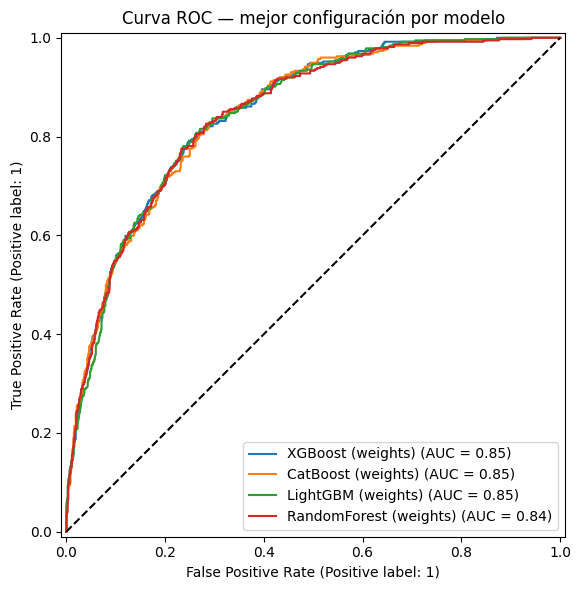

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, fila in mejores.iterrows():
    est = TODOS_RESULTADOS[fila['Modelo']]['random_search'][fila['Balanceo']]['estimator']
    RocCurveDisplay.from_estimator(
        est, X_test, y_test, ax=ax,
        name=f"{fila['Modelo']} ({fila['Balanceo']})"
    )

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title('Curva ROC — mejor configuración por modelo')
plt.tight_layout()
plt.show()

Las curvas ROC de los cuatro modelos con sus mejores configuraciones muestran un rendimiento muy similar. XGBoost, CatBoost y LightGBM alcanzan un AUC de 0.85, mientras que Random Forest obtiene un AUC de 0.84, apenas un punto porcentual por debajo. Esta similitud indica que todos los modelos tienen una capacidad discriminativa prácticamente equivalente para separar las clases en el conjunto de prueba.

### 9.5 Classification report 

In [22]:
for _, fila in mejores.iterrows():
    est    = TODOS_RESULTADOS[fila['Modelo']]['random_search'][fila['Balanceo']]['estimator']
    y_pred = est.predict(X_test)
    print(f"\n{'='*55}")
    print(f"  {fila['Modelo']} — balanceo: {fila['Balanceo']}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


  XGBoost — balanceo: weights
              precision    recall  f1-score   support

    No Churn       0.90      0.77      0.83      1035
       Churn       0.55      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409


  CatBoost — balanceo: weights
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409


  LightGBM — balanceo: weights
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.82      1035
       Churn       0.53      0.80      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77

El error más costoso para el negocio es el falso negativo, predecir que un cliente no abandonará cuando en realidad sí lo hace, ya que implica perderlo sin oportunidad de retenerlo. XGBoost con pesos balanceados es el modelo que menos falsos negativos comete, con un recall para la clase Churn de 0.75, lo que significa que solo deja de detectar el 25% de los abandonos reales. Random Forest con pesos le sigue con un recall de 0.78, aunque su informe indica 0.78, lo que equivale a un 22% de falsos negativos. CatBoost con pesos alcanza un recall de 0.79, dejando sin detectar el 21% de los abandonos. LightGBM con pesos obtiene el recall más alto, 0.80, con solo un 20% de falsos negativos.

### 9.6 Importancia de características

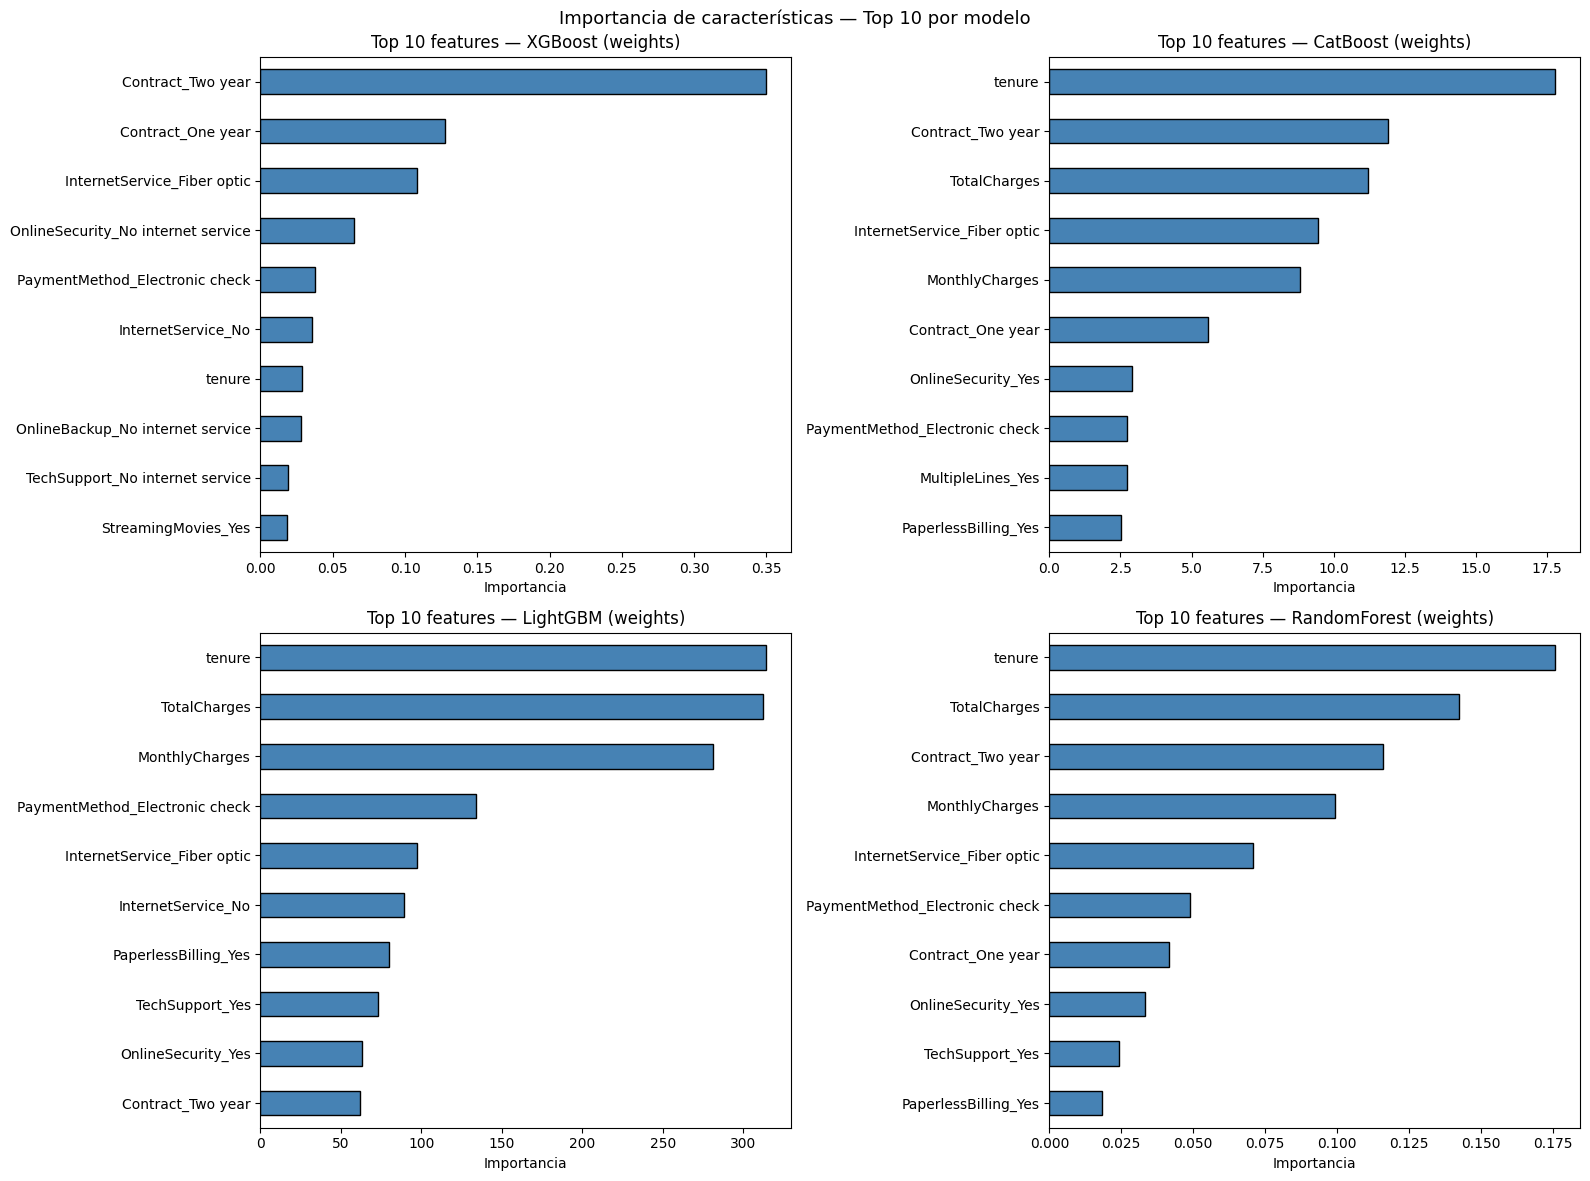

In [23]:
def get_feature_names_out(estimator):
    prep      = estimator.named_steps['preprocessor']
    num_names = FEATURES_NUM
    cat_names = prep.named_transformers_['cat']['onehot']\
                    .get_feature_names_out(FEATURES_CAT).tolist()
    return num_names + cat_names


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (_, fila) in enumerate(mejores.iterrows()):
    est = TODOS_RESULTADOS[fila['Modelo']]['random_search'][fila['Balanceo']]['estimator']
    clf = est.named_steps['classifier']

    if hasattr(clf, 'feature_importances_'):
        feat_names   = get_feature_names_out(est)
        importancias = pd.Series(clf.feature_importances_, index=feat_names)
        top10        = importancias.nlargest(10).sort_values()
        top10.plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='black')
        axes[i].set_title(f"Top 10 features — {fila['Modelo']} ({fila['Balanceo']})")
        axes[i].set_xlabel('Importancia')
    else:
        axes[i].text(0.5, 0.5, f"{fila['Modelo']}\nno tiene feature_importances_",
                     ha='center', va='center', transform=axes[i].transAxes)

plt.suptitle('Importancia de características — Top 10 por modelo', fontsize=13)
plt.tight_layout()
plt.show()

Las variables más importantes de forma consistente entre los modelos son Contract, InternetService y tenure, lo cual coincide directamente con los hallazgos del análisis exploratorio. Contract es la variable con mayor peso en todos los modelos, las categorías de contrato a dos años y a un año aparecen en los primeros lugares, confirmando el EDA donde los contratos mes a mes presentaban las tasas de churn más altas. InternetService con fibra óptica también aparece de forma consistente, reflejando que este tipo de conexión fue identificada en el EDA como un factor de riesgo relevante con tasas de churn elevadas.

Tenure se mantiene entre las variables importantes, lo que coincide con su correlación negativa de -0.35 con Churn detectada en el EDA. Los servicios de seguridad y soporte como OnlineSecurity y TechSupport aparecen representados principalmente a través de sus categorías "No internet service", lo que indica que la ausencia de estos servicios por no tener internet contratado también influye en la predicción. PaymentMethod con cheque electrónico aparece en varios modelos, alineándose con las tasas de churn más altas observadas en esta categoría durante el EDA. Otras variables como OnlineBackup y StreamingMovies tienen menor peso pero complementan la información. Las variables Partner y Dependents, que en el EDA mostraron diferencias en las tasas de churn, no aparecen en los primeros lugares, lo que sugiere que su efecto es capturado indirectamente por otras variables con mayor poder predictivo.

## 10. Guardado del modelo final y archivos para LIME

### 10.1 Selección del modelo final

In [24]:
fila_ganadora = df_comparacion.sort_values('ROC_AUC_test', ascending=False).iloc[0]
mejor_modelo_nombre  = fila_ganadora['Modelo']
mejor_balanceo       = fila_ganadora['Balanceo']
mejor_estimator      = TODOS_RESULTADOS[mejor_modelo_nombre]['random_search'][mejor_balanceo]['estimator']
mejores_params       = TODOS_RESULTADOS[mejor_modelo_nombre]['random_search'][mejor_balanceo]['params']

print(f'Modelo seleccionado:  {mejor_modelo_nombre}')
print(f'Técnica de balanceo:  {mejor_balanceo}')
print(f'ROC-AUC test:         {fila_ganadora["ROC_AUC_test"]}')
print(f'PR-AUC test:          {fila_ganadora["PR_AUC_test"]}')
print(f'F1 test (Churn):      {fila_ganadora["F1_test"]}')
print(f'Recall test (Churn):  {fila_ganadora["Recall_test"]}')
print(f'\nMejores hiperparámetros: {mejores_params}')

Modelo seleccionado:  XGBoost
Técnica de balanceo:  weights
ROC-AUC test:         0.8474
PR-AUC test:          0.6653
F1 test (Churn):      0.6322
Recall test (Churn):  0.7513

Mejores hiperparámetros: {'classifier__colsample_bytree': np.float64(0.6571467271687763), 'classifier__gamma': np.float64(0.32544423647442644), 'classifier__learning_rate': np.float64(0.012115092723815248), 'classifier__max_depth': 6, 'classifier__min_child_weight': 6, 'classifier__n_estimators': 179, 'classifier__reg_alpha': np.float64(0.000533703276260396), 'classifier__reg_lambda': np.float64(0.20492680115417347), 'classifier__scale_pos_weight': np.float64(2.263470210979458), 'classifier__subsample': np.float64(0.8099025726528951)}


In [28]:
ruta_modelo = os.path.join('..', 'app', 'model.joblib')
os.makedirs(os.path.dirname(ruta_modelo), exist_ok=True)
joblib.dump(mejor_estimator, ruta_modelo)
print(f'Modelo guardado en "{ruta_modelo}"')

Modelo guardado en "../app/model.joblib"


### 10.2 Datos de train/test

In [29]:
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv',   index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv',   index=False)

print('Archivos train/test guardados')
print(f'   X_train: {X_train.shape} | X_test: {X_test.shape}')

Archivos train/test guardados
   X_train: (5634, 19) | X_test: (1409, 19)


### 10.3 Archivos de metadatos categóricos para LIME

`LimeTabularExplainer` necesita los índices de las columnas categóricas en X **original** (antes del OHE) y sus valores posibles para generar perturbaciones correctas.

In [30]:
feature_names       = X_train.columns.tolist()
categorical_indices = [feature_names.index(c) for c in FEATURES_CAT]
categorical_names   = {
    str(feature_names.index(col)): sorted(X_train[col].dropna().unique().tolist())
    for col in FEATURES_CAT
}

with open('../data/feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)
with open('../data/categorical_features.json', 'w') as f:
    json.dump(categorical_indices, f, indent=2)
with open('../data/categorical_names.json', 'w') as f:
    json.dump(categorical_names, f, indent=2)

print('Archivos para LIME guardados:')
print(f'   feature_names.json        ({len(feature_names)} features)')
print(f'   categorical_features.json ({len(categorical_indices)} categóricas)')
print(f'   categorical_names.json')

Archivos para LIME guardados:
   feature_names.json        (19 features)
   categorical_features.json (15 categóricas)
   categorical_names.json


## Conclusiones del modelado

La técnica de balanceo que funcionó mejor en general fue weights, es decir, el uso de pesos balanceados propios de cada algoritmo, superando a SMOTE y ADASYN en F1, recall y eficiencia. Esto difiere del hallazgo del notebook de fraude donde sin balanceo ganó, lo cual tiene sentido porque en fraude el desbalance suele ser mucho más extremo y la clase minoritaria es aún más escasa, haciendo que técnicas como SMOTE generen ruido. En churn, con un ratio de 2.77 a 1, los pesos balanceados lograron mejorar significativamente la detección sin necesidad de generar datos sintéticos.

El modelo ganador fue XGBoost con pesos balanceados. Obtuvo el mejor F1 en test con 0.6322, un ROC-AUC de 0.8474, el PR-AUC más alto con 0.6653 y un recall de 0.7513. Aunque LightGBM y CatBoost alcanzaron recalls ligeramente superiores, cercanos a 0.79, lo hicieron con precisiones más bajas y mayores tiempos de entrenamiento. XGBoost ofreció el mejor equilibrio entre todas las métricas, destacando en PR-AUC que es especialmente relevante en contextos desbalanceados, y además fue el más rápido con solo 0.02 minutos de entrenamiento.

Las variables más importantes para predecir churn fueron Contract, principalmente las categorías de contrato a dos años y a un año, InternetService en su categoría de fibra óptica, tenure, OnlineSecurity, TechSupport y PaymentMethod con cheque electrónico. Estas coinciden con los hallazgos del EDA, donde los clientes con contrato mes a mes, fibra óptica, baja antigüedad y sin servicios de soporte presentaban las tasas de abandono más altas.